<a href="https://colab.research.google.com/github/judeaq/BASEER/blob/main/BASEER_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snalyami3/arabic-sentiment-analysis-dataset-ss2030-dataset")

print("Path to dataset files:", path)


100%|██████████| 337k/337k [00:00<00:00, 485kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/snalyami3/arabic-sentiment-analysis-dataset-ss2030-dataset/versions/1


In [ ]:
import os

os.listdir(path)

['Arabic Sentiment Analysis Dataset - SS2030.csv']

In [ ]:
import numpy as np
import random

seed = 42

np.random.seed(seed)
random.seed(seed)

# Explore the Data

In [ ]:
import pandas as pd
df=pd.read_csv(os.path.join(path, "Arabic Sentiment Analysis Dataset - SS2030.csv"),encoding="utf-8")
df.head(50)

,text,Sentiment
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1
1,RT @___IHAVENOIDEA: حقوق المرأة في الإسلام. ht...,1
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1
3,RT @MojKsa: حقوق المرأة التي تضمنها لها وزارة ...,1
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1
5,RT @fatemaar7: انا كامرأة يوجعني كل حزن نساء ا...,1
6,@Samar_K_ 😂😂😂😂😂\n اومن حقوق المرأة \n أنك تفتح...,1
7,@AliFCD @ShamsanM @AlyemenNor @space_dist @m2r...,1
8,مبدائيا انا مع حقوق المرأة وضد حقوق الرجل 😁,1
9,RT @Dresraamohammed: السؤال بقى للناس الي شغال...,1


In [ ]:
df.loc[300:330]


,text,Sentiment
300,#سعوديات_نطلب_اسقاط_الولايه804\n #حملة_إلغاء_ش...,1
301,#سعوديات_نطلب_اسقاط_الولايه804\n يقولو ان الول...,1
302,#سعوديات_نطلب_اسقاط_الولايه804\n 🌈\n تسقط الول...,1
303,#ماذا_نتعلم_من_هجره_النبي نتعلم انه ليس من حق ...,1
304,@0_____93 انا مع اسقاط الولاية بس بعد صورتك هو...,1
305,@4heend4444 اتفق معك بجماعة اسقاط الولاية 💗,1
306,@5__IIM اسقاط الولاية والسفر من دون اذن,1
307,@6ixty11 #اسقاط_الولاية #حريه,1
308,@9fa836caa8bb4f6 آمين يارب وياك.. وشكرًا ع الن...,1
309,@A1bdn @SaudiNews50 والله محد درا عنك الله يعي...,1


In [ ]:
for col in df.columns:
    print(col)

text
Sentiment


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       4252 non-null   object
 1   Sentiment  4252 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 66.6+ KB


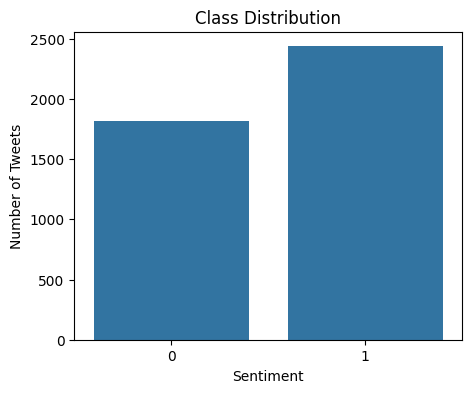

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Class Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
#check if the data is balanced or not
df["Sentiment"].value_counts()


,count
Sentiment,
1,2436
0,1816


In [ ]:
df.shape

(4252, 2)

In [ ]:
df.size

8504

# Preprocessing

**Base Cleaning**

In [ ]:
#Remove Noisy
import re
df_cln = df.copy()
def clean_text(text):
    text = str(text)

    # remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # remove hashtag symbol only (#word → word)
    text = re.sub(r'#', '', text)
    text = text.replace('_', ' ')

    # remove punctuation and symbols
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # remove tashkeel (diacritics)
    text = re.sub(r'[\u064B-\u065F\u0617-\u061A\u06D6-\u06ED]', '', text)

    # remove unmeaning eng world
    text = re.sub(r'\bRT\b|\bRetweeted\b', '', text)

    # remove repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_cln["text"] = df_cln["text"].apply(clean_text)
df_cln.head(30)

,text,Sentiment
0,حقوق المرأة,1
1,حقوق المرأة في الإسلام,1
2,لجنة التنمية بشبرا ما زال التسجيل مستمر في دور...,1
3,حقوق المرأة التي تضمنها لها وزارة العدل,1
4,ولي امر الزوجة او ولي الزوجة او ولي المراة من ...,1
5,انا كامرأة يوجعني كل حزن نساء العالم، سواء تعن...,1
6,اومن حقوق المرأة أنك تفتحلها الباب,1
7,غسق و سبيس و حلوة الحلوات هم اشخاص لهم هويتهم ...,1
8,مبدائيا انا مع حقوق المرأة وضد حقوق الرجل,1
9,السؤال بقى للناس الي شغاله في حقوق الانسان حقو...,1


In [ ]:
#Normalization
def normalize_arabic(text):
    text = str(text)

    # normalize Alef forms
    text = re.sub(r'[إأآا]', 'ا', text)

    # normalize Ya
    text = re.sub(r'ى', 'ي', text)

    # normalize Ta marbuta
    text = re.sub(r'ة', 'ه', text)

    # remove (ـ)
    text = re.sub(r'ـ', '', text)

    return text

df_cln["text"] = df_cln["text"].apply(normalize_arabic)
df_cln

,text,Sentiment
0,حقوق المراه,1
1,حقوق المراه في الاسلام,1
2,لجنه التنميه بشبرا ما زال التسجيل مستمر في دور...,1
3,حقوق المراه التي تضمنها لها وزاره العدل,1
4,ولي امر الزوجه او ولي الزوجه او ولي المراه من ...,1
...,...,...
4247,غرد بحبك لمحمد بن سلمان,1
4248,غرد بحبك لمحمد بن سلمان محمدبن سلمان احبه الله...,1
4249,غرد بحبك لمحمد بن سلمان الله يحفظك يا ذخر الوط...,1
4250,غرد بحبك لمحمد بن سلمان الله يحفظه ويحميه ويقو...,1


**Stemming**

In [ ]:
from nltk.stem.isri import ISRIStemmer

Root Stemming

In [ ]:
#Root Stemming
df_root = df_cln.copy()
def root_stem(text):

    stemmer = ISRIStemmer()

    words = text.split()

    stemmed_words = []

    for word in words:
        stemmed_word = stemmer.stem(word)
        stemmed_words.append(stemmed_word)

    return " ".join(stemmed_words)
df_root["text"] = df_root["text"].apply(root_stem)
print(df_cln["text"].iloc[0])
print(df_root["text"].iloc[0])

حقوق المراه
حقق راه


Light Stemming

In [ ]:
#Light Stemming
df_light = df_cln.copy()
def light_stem(text):

    stemmer = ISRIStemmer()
    words = text.split()
    stemmed_words = []
    for word in words:
        word = stemmer.norm(word, num=1)
        if word not in stemmer.stop_words:
            word = stemmer.pre32(word)
            word = stemmer.suf32(word)
            word = stemmer.waw(word)
            word = stemmer.norm(word, num=2)
        stemmed_words.append(word)
    return " ".join(stemmed_words)

df_light["text"] = df_light["text"].apply(light_stem)
print(df_cln["text"].iloc[0])
print(df_light["text"].iloc[0])

حقوق المراه
حقوق مراه


# Split data

In [ ]:
from sklearn.model_selection import train_test_split

#Split root data
X_train_root, X_test_root, y_train_root, y_test_root = train_test_split(
    df_root["text"],
    df_root["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df_root["Sentiment"])

#split light data
X_train_light, X_test_light, y_train_light, y_test_light = train_test_split(
    df_light["text"],
    df_light["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df_light["Sentiment"]
)

# Feature Extraction

TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#TF-IDF with Root Stemming
tfidf_root = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    max_features=5000
)
X_train_tfr = tfidf_root.fit_transform(X_train_root)
X_test_tfr = tfidf_root.transform(X_test_root)

#TF-IDF with Light Stemming
tfidf_light = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    max_features=5000
)

X_train_tfl = tfidf_light.fit_transform(X_train_light)
X_test_tfl = tfidf_light.transform(X_test_light)


Character N-grams

In [ ]:
#N-grams with Light Stemming
char_light = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=5000
)

X_train_chl = char_light.fit_transform(X_train_light)
X_test_chl = char_light.transform(X_test_light)

#N-grams with Root Stemming
char_root = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=5000
)

X_train_chr = char_root.fit_transform(X_train_root)
X_test_chr = char_root.transform(X_test_root)

FastText

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.0 MB/s eta 0:00:00


In [ ]:
from gensim.models import FastText
import numpy as np

In [ ]:
#FastText with root

#split words to be list
root_sentences = X_train_root.apply(lambda x: x.split()).tolist()

#train the FT
ft_root = FastText(
    sentences=root_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)
#convert word to be a vector
def sentence_vector(model, sentence):
    words = sentence.split()
    vectors = []

    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)
X_train_ft_root = np.array([
    sentence_vector(ft_root, text)
    for text in X_train_root
])

X_test_ft_root = np.array([
 sentence_vector(ft_root, text)
    for text in X_test_root
])

#FastText with Light
light_sentences = X_train_light.apply(lambda x: x.split()).tolist()

ft_light = FastText(
    sentences=light_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)
X_train_ft_light = np.array([
    sentence_vector(ft_light, text)
    for text in X_train_light
])

X_test_ft_light = np.array([
    sentence_vector(ft_light, text)
    for text in X_test_light
])

# Build Modeld

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def cross_validate_model(model, X_train, y_train, model_name):
    scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )
    print(f"\n===== {model_name} =====")
    print("Fold Scores:", scores)
    print("Mean F1:", scores.mean())
    print("Std:", scores.std())

    return {
        "Model": model_name,
        "CV Mean F1": scores.mean(),
        "CV Std": scores.std()
    }

In [ ]:
import joblib

def train_model(model, X_train, y_train, model_name, save_name):
    # Train
    model.fit(X_train, y_train)

    # Cross Validation
    cv_results.append(
        cross_validate_model(
            model,
            X_train,
            y_train,
            model_name
        )
    )

    # Save Model
    joblib.dump(model, save_name)

    return model

In [ ]:
cv_results = []

SVM

In [ ]:
from sklearn import svm

svm_root_TF = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfr,
    y_train_root,
    "Root TFIDF SVM",
    "svm_root.pkl"
)

svm_light_TF = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfl,
    y_train_light,
    "Light TFIDF SVM",
    "svm_light.pkl"
)

svm_root_char = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_chr,
    y_train_root,
    "Root CHAR SVM",
    "svm_root_char.pkl"
)

svm_light_char = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_chl,
    y_train_light,
    "Light CHAR SVM",
    "svm_light_char.pkl"
)

svm_root_fasttext = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_ft_root,
    y_train_root,
    "Root FastText SVM",
    "svm_root_fasttext.pkl"
)

svm_light_fasttext = train_model(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_ft_light,
    y_train_light,
    "Light FastText SVM",
    "svm_light_fasttext.pkl"
)



===== Root TFIDF SVM =====
Fold Scores: [0.88899362 0.88501391 0.88524235 0.87564821 0.89131179 0.87386407
 0.87347233 0.86770435 0.90805168 0.86746785]
Mean F1: 0.8816770171500596
Std: 0.011948524785323671

===== Light TFIDF SVM =====
Fold Scores: [0.88585055 0.90588235 0.86444654 0.8873372  0.89701236 0.90319801
 0.86458125 0.87667088 0.90225322 0.87647059]
Mean F1: 0.8863702944460414
Std: 0.014758437310389437

===== Root CHAR SVM =====
Fold Scores: [0.86233669 0.84604064 0.86444654 0.85519981 0.87667088 0.87696403
 0.85233321 0.8768352  0.87912845 0.87021614]
Mean F1: 0.8660171583235355
Std: 0.011221597142386339

===== Light CHAR SVM =====
Fold Scores: [0.86198078 0.86127378 0.86758732 0.87005323 0.88849488 0.87986524
 0.85869348 0.87088881 0.88779008 0.89411765]
Mean F1: 0.8740745250887809
Std: 0.012026720763802502

===== Root FastText SVM =====
Fold Scores: [0.74320443 0.75294118 0.76852083 0.73372092 0.79196176 0.77735343
 0.74507991 0.72474845 0.7540452  0.75598354]
Mean F1: 0.

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_root_tfidf = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfr,
    y_train_root,
    "Root TFIDF LR",
    "lr_root_tfidf.pkl"
)

lr_light_tfidf = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfl,
    y_train_light,
    "Light TFIDF LR",
    "lr_light_tfidf.pkl"
)

lr_root_char = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_chr,
    y_train_root,
    "Root CHAR LR",
    "lr_root_char.pkl"
)

lr_light_char = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_chl,
    y_train_light,
    "Light CHAR LR",
    "lr_light_char.pkl"
)

lr_root_fasttext = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_ft_root,
    y_train_root,
    "Root FastText LR",
    "lr_root_fasttext.pkl"
)
lr_light_fasttext = train_model(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ),
    X_train_ft_light,
    y_train_light,
    "Light FastText LR",
    "lr_light_fasttext.pkl"
)


===== Root TFIDF LR =====
Fold Scores: [0.88585055 0.89980831 0.90023226 0.88501391 0.88254369 0.88566567
 0.85869348 0.87965066 0.88448108 0.86129195]
Mean F1: 0.8823231558146019
Std: 0.012922239663161061

===== Light TFIDF LR =====
Fold Scores: [0.89170436 0.89411765 0.87347233 0.88200146 0.89691371 0.89167599
 0.87046902 0.88559764 0.91711765 0.86470588]
Mean F1: 0.886777569053887
Std: 0.014421397782347347

===== Root CHAR LR =====
Fold Scores: [0.85337243 0.85519981 0.86182454 0.85855291 0.86182454 0.85956203
 0.8499323  0.8767575  0.86719442 0.8673361 ]
Mean F1: 0.861155658875871
Std: 0.0074182563642390936

===== Light CHAR LR =====
Fold Scores: [0.85596275 0.83766081 0.85594474 0.88224456 0.88823529 0.85373016
 0.8499323  0.86234678 0.88502462 0.87358183]
Mean F1: 0.8644663848782376
Std: 0.01606619174596302

===== Root FastText LR =====
Fold Scores: [0.74909703 0.74964758 0.76239511 0.71625673 0.76540038 0.76883464
 0.71261547 0.70976669 0.72744516 0.73506007]
Mean F1: 0.7396518

Cross Validation

In [ ]:
cv_results = pd.DataFrame(cv_results)
cv_results

,Model,CV Mean F1,CV Std
0,Root TFIDF SVM,0.881677,0.011949
1,Light TFIDF SVM,0.886370,0.014758
2,Root CHAR SVM,0.866017,0.011222
3,Light CHAR SVM,0.874075,0.012027
4,Root FastText SVM,0.754756,0.019130
5,Light FastText SVM,0.755259,0.014403
6,Root TFIDF LR,0.882323,0.012922
7,Light TFIDF LR,0.886778,0.014421
8,Root CHAR LR,0.861156,0.007418
9,Light CHAR LR,0.864466,0.016066


# Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n===== {title} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1


===== Root TFIDF SVM =====
Accuracy: 0.8918918918918919
Precision: 0.8917743750952528
Recall: 0.8918918918918919
F1-score: 0.8918130522404365

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       363
           1       0.90      0.91      0.91       488

    accuracy                           0.89       851
   macro avg       0.89      0.89      0.89       851
weighted avg       0.89      0.89      0.89       851



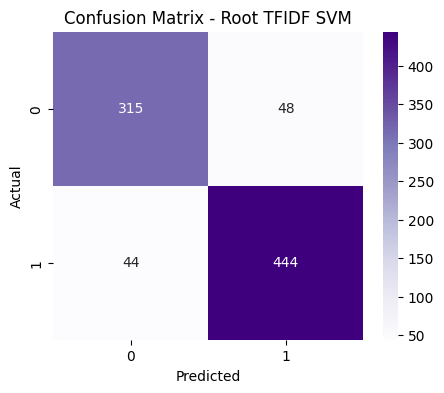

(0.8918918918918919,
 0.8917743750952528,
 0.8918918918918919,
 0.8918130522404365)

In [ ]:
evaluate_model(svm_root_TF, X_test_tfr, y_test_root, "Root TFIDF SVM")


===== Root TFIDF LR =====
Accuracy: 0.8777908343125734
Precision: 0.877571249769737
Recall: 0.8777908343125734
F1-score: 0.8775571402866037

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.84      0.85       363
           1       0.89      0.90      0.89       488

    accuracy                           0.88       851
   macro avg       0.88      0.87      0.87       851
weighted avg       0.88      0.88      0.88       851



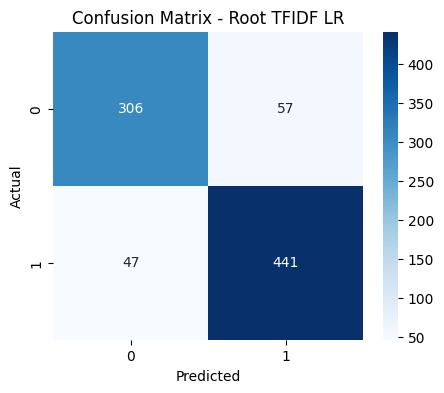

(0.8777908343125734, 0.877571249769737, 0.8777908343125734, 0.8775571402866037)

In [ ]:
evaluate_model(lr_root_tfidf, X_test_tfr, y_test_root, "Root TFIDF LR")


===== Light TFIDF SVM =====
Accuracy: 0.8742655699177438
Precision: 0.8741841529816952
Recall: 0.8742655699177438
F1-score: 0.8737765485723962

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       363
           1       0.88      0.91      0.89       488

    accuracy                           0.87       851
   macro avg       0.87      0.87      0.87       851
weighted avg       0.87      0.87      0.87       851



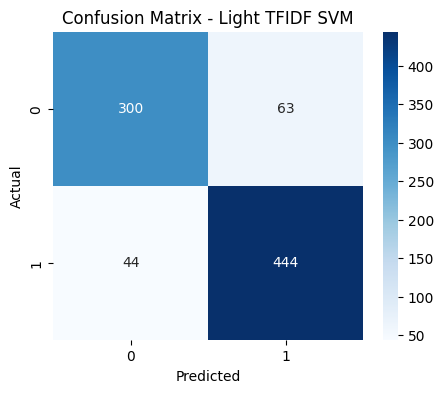

(0.8742655699177438,
 0.8741841529816952,
 0.8742655699177438,
 0.8737765485723962)

In [ ]:
evaluate_model(svm_light_TF, X_test_tfl, y_test_light, "Light TFIDF SVM")


===== Light TFIDF LR =====
Accuracy: 0.8660399529964747
Precision: 0.8659192367735011
Recall: 0.8660399529964747
F1-score: 0.865487482297375

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       363
           1       0.87      0.90      0.89       488

    accuracy                           0.87       851
   macro avg       0.87      0.86      0.86       851
weighted avg       0.87      0.87      0.87       851



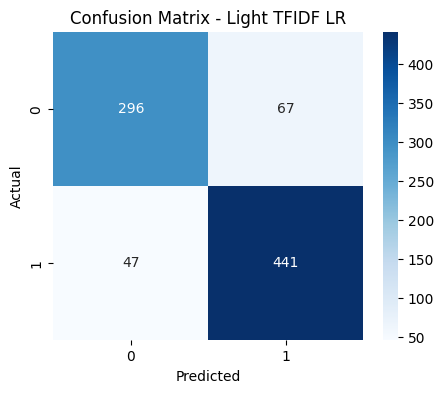

(0.8660399529964747, 0.8659192367735011, 0.8660399529964747, 0.865487482297375)

In [ ]:
evaluate_model(lr_light_tfidf, X_test_tfl, y_test_light, "Light TFIDF LR")


===== Root CHAR SVM =====
Accuracy: 0.8683901292596945
Precision: 0.8681503066387407
Recall: 0.8683901292596945
F1-score: 0.8681919261117399

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       363
           1       0.88      0.89      0.89       488

    accuracy                           0.87       851
   macro avg       0.87      0.86      0.87       851
weighted avg       0.87      0.87      0.87       851



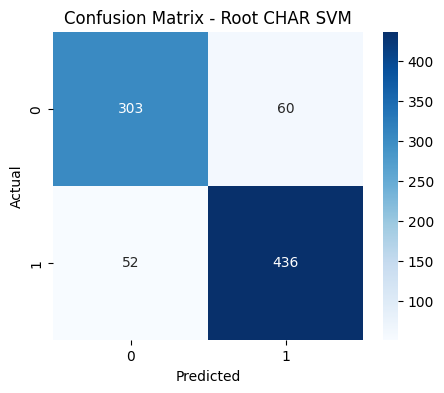

(0.8683901292596945,
 0.8681503066387407,
 0.8683901292596945,
 0.8681919261117399)

In [ ]:
evaluate_model(svm_root_char, X_test_chr, y_test_root, "Root CHAR SVM")


===== Root CHAR LR =====
Accuracy: 0.8613396004700352
Precision: 0.8611760722283353
Recall: 0.8613396004700352
F1-score: 0.8612384800475164

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.83      0.84       363
           1       0.88      0.88      0.88       488

    accuracy                           0.86       851
   macro avg       0.86      0.86      0.86       851
weighted avg       0.86      0.86      0.86       851



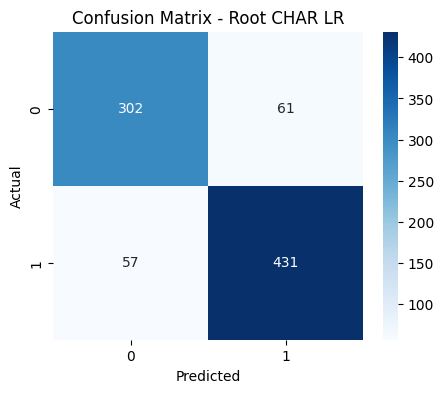

(0.8613396004700352,
 0.8611760722283353,
 0.8613396004700352,
 0.8612384800475164)

In [ ]:
evaluate_model(lr_root_char, X_test_chr, y_test_root, "Root CHAR LR")


===== Light CHAR SVM =====
Accuracy: 0.8660399529964747
Precision: 0.8661426034597894
Recall: 0.8660399529964747
F1-score: 0.8660864280675011

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       363
           1       0.88      0.88      0.88       488

    accuracy                           0.87       851
   macro avg       0.86      0.86      0.86       851
weighted avg       0.87      0.87      0.87       851



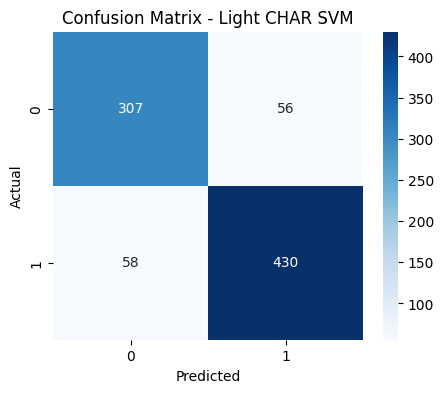

(0.8660399529964747,
 0.8661426034597894,
 0.8660399529964747,
 0.8660864280675011)

In [ ]:
evaluate_model(svm_light_char, X_test_chl, y_test_light, "Light CHAR SVM")


===== Light CHAR LR =====
Accuracy: 0.8531139835487661
Precision: 0.8530641170829567
Recall: 0.8531139835487661
F1-score: 0.8530878548111487

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       363
           1       0.87      0.87      0.87       488

    accuracy                           0.85       851
   macro avg       0.85      0.85      0.85       851
weighted avg       0.85      0.85      0.85       851



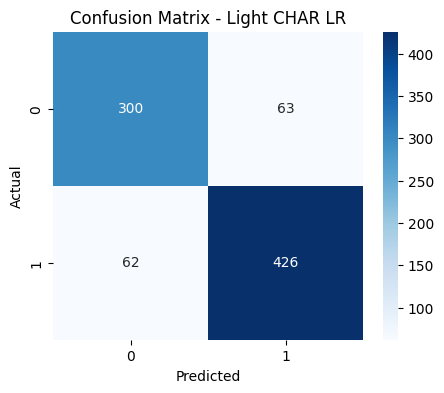

(0.8531139835487661,
 0.8530641170829567,
 0.8531139835487661,
 0.8530878548111487)

In [ ]:
evaluate_model(lr_light_char, X_test_chl, y_test_light, "Light CHAR LR")


===== Root FastText SVM =====
Accuracy: 0.7391304347826086
Precision: 0.743739799115855
Recall: 0.7391304347826086
F1-score: 0.7402578378929877

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       363
           1       0.79      0.74      0.76       488

    accuracy                           0.74       851
   macro avg       0.74      0.74      0.74       851
weighted avg       0.74      0.74      0.74       851



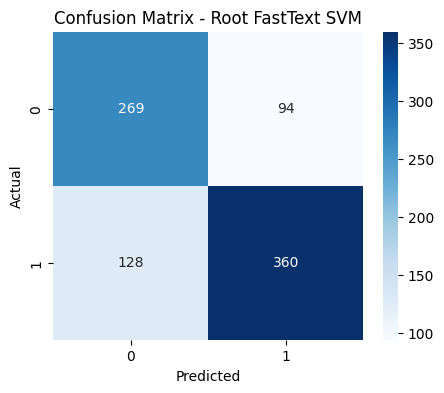


===== Light FastText SVM =====
Accuracy: 0.7379553466509988
Precision: 0.7464458389308464
Recall: 0.7379553466509988
F1-score: 0.7393460820538889

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.77      0.71       363
           1       0.80      0.72      0.76       488

    accuracy                           0.74       851
   macro avg       0.74      0.74      0.74       851
weighted avg       0.75      0.74      0.74       851



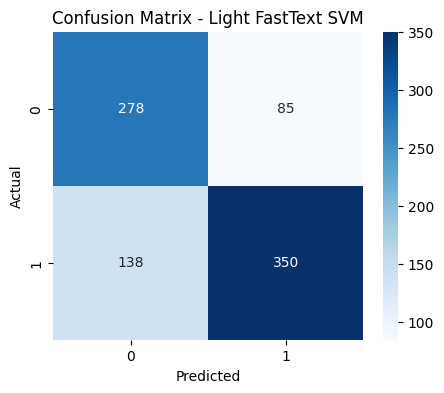


===== Root FastText LR =====
Accuracy: 0.7144535840188014
Precision: 0.7190183494531321
Recall: 0.7144535840188014
F1-score: 0.7156648095372795

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.71      0.68       363
           1       0.77      0.72      0.74       488

    accuracy                           0.71       851
   macro avg       0.71      0.71      0.71       851
weighted avg       0.72      0.71      0.72       851



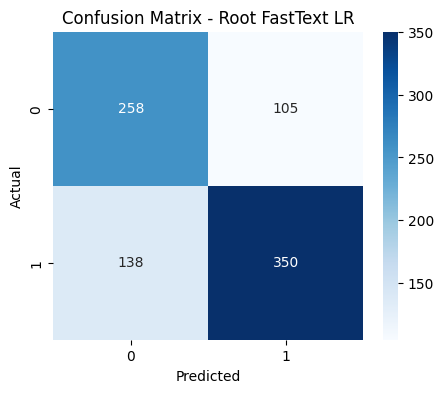


===== Light FastText LR =====
Accuracy: 0.7226792009400705
Precision: 0.7273770108041895
Recall: 0.7226792009400705
F1-score: 0.723877701543897

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.72      0.69       363
           1       0.78      0.72      0.75       488

    accuracy                           0.72       851
   macro avg       0.72      0.72      0.72       851
weighted avg       0.73      0.72      0.72       851



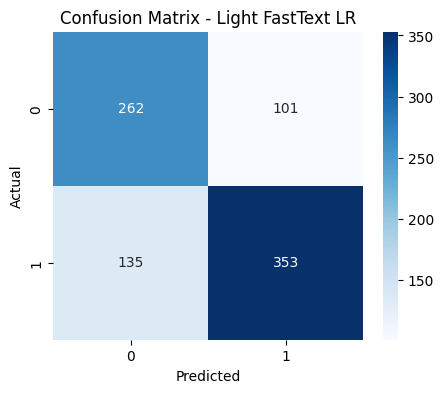

(0.7226792009400705, 0.7273770108041895, 0.7226792009400705, 0.723877701543897)

In [ ]:
# FastText SVM
evaluate_model(
    svm_root_fasttext,
    X_test_ft_root,
    y_test_root,
    "Root FastText SVM"
)

evaluate_model(
    svm_light_fasttext,
    X_test_ft_light,
    y_test_light,
    "Light FastText SVM"
)

# FastText LR
evaluate_model(
    lr_root_fasttext,
    X_test_ft_root,
    y_test_root,
    "Root FastText LR"
)

evaluate_model(
    lr_light_fasttext,
    X_test_ft_light,
    y_test_light,
    "Light FastText LR"
)

# Analysis the Result

In [ ]:
results = []
results.append([
    "Root TFIDF SVM",
    accuracy_score(y_test_root, svm_root_TF.predict(X_test_tfr)),
    precision_score(y_test_root, svm_root_TF.predict(X_test_tfr), average='weighted'),
    recall_score(y_test_root, svm_root_TF.predict(X_test_tfr), average='weighted'),
    f1_score(y_test_root, svm_root_TF.predict(X_test_tfr), average='weighted')
])

results.append([
    "Light TFIDF SVM",
    accuracy_score(y_test_light, svm_light_TF.predict(X_test_tfl)),
    precision_score(y_test_light, svm_light_TF.predict(X_test_tfl), average='weighted'),
    recall_score(y_test_light, svm_light_TF.predict(X_test_tfl), average='weighted'),
    f1_score(y_test_light, svm_light_TF.predict(X_test_tfl), average='weighted')
])

results.append([
    "Root CHAR SVM",
    accuracy_score(y_test_root, svm_root_char.predict(X_test_chr)),
    precision_score(y_test_root, svm_root_char.predict(X_test_chr), average='weighted'),
    recall_score(y_test_root, svm_root_char.predict(X_test_chr), average='weighted'),
    f1_score(y_test_root, svm_root_char.predict(X_test_chr), average='weighted')
])

results.append([
    "Light CHAR SVM",
    accuracy_score(y_test_light, svm_light_char.predict(X_test_chl)),
    precision_score(y_test_light, svm_light_char.predict(X_test_chl), average='weighted'),
    recall_score(y_test_light, svm_light_char.predict(X_test_chl), average='weighted'),
    f1_score(y_test_light, svm_light_char.predict(X_test_chl), average='weighted')
])

results.append([
    "Root FastText SVM",
    accuracy_score(y_test_root, svm_root_fasttext.predict(X_test_ft_root)),
    precision_score(y_test_root, svm_root_fasttext.predict(X_test_ft_root), average='weighted'),
    recall_score(y_test_root, svm_root_fasttext.predict(X_test_ft_root), average='weighted'),
    f1_score(y_test_root, svm_root_fasttext.predict(X_test_ft_root), average='weighted')
])

results.append([
    "Light FastText SVM",
    accuracy_score(y_test_light, svm_light_fasttext.predict(X_test_ft_light)),
    precision_score(y_test_light, svm_light_fasttext.predict(X_test_ft_light), average='weighted'),
    recall_score(y_test_light, svm_light_fasttext.predict(X_test_ft_light), average='weighted'),
    f1_score(y_test_light, svm_light_fasttext.predict(X_test_ft_light), average='weighted')
])

#--------------LR-----------------
results.append([
    "Root TFIDF LR",
    accuracy_score(y_test_root, lr_root_tfidf.predict(X_test_tfr)),
    precision_score(y_test_root, lr_root_tfidf.predict(X_test_tfr), average='weighted'),
    recall_score(y_test_root, lr_root_tfidf.predict(X_test_tfr), average='weighted'),
    f1_score(y_test_root, lr_root_tfidf.predict(X_test_tfr), average='weighted')
])
results.append([
    "Light TFIDF LR",
    accuracy_score(y_test_light, lr_light_tfidf.predict(X_test_tfl)),
    precision_score(y_test_light, lr_light_tfidf.predict(X_test_tfl), average='weighted'),
    recall_score(y_test_light, lr_light_tfidf.predict(X_test_tfl), average='weighted'),
    f1_score(y_test_light, lr_light_tfidf.predict(X_test_tfl), average='weighted')
])
results.append([
    "Root CHAR LR",
    accuracy_score(y_test_root, lr_root_char.predict(X_test_chr)),
    precision_score(y_test_root, lr_root_char.predict(X_test_chr), average='weighted'),
    recall_score(y_test_root, lr_root_char.predict(X_test_chr), average='weighted'),
    f1_score(y_test_root, lr_root_char.predict(X_test_chr), average='weighted')
])
results.append([
    "Light CHAR LR",
    accuracy_score(y_test_light, lr_light_char.predict(X_test_chl)),
    precision_score(y_test_light, lr_light_char.predict(X_test_chl), average='weighted'),
    recall_score(y_test_light, lr_light_char.predict(X_test_chl), average='weighted'),
    f1_score(y_test_light, lr_light_char.predict(X_test_chl), average='weighted')
])

results.append([
    "Root FastText LR",
    accuracy_score(y_test_root, lr_root_fasttext.predict(X_test_ft_root)),
    precision_score(y_test_root, lr_root_fasttext.predict(X_test_ft_root), average='weighted'),
    recall_score(y_test_root, lr_root_fasttext.predict(X_test_ft_root), average='weighted'),
    f1_score(y_test_root, lr_root_fasttext.predict(X_test_ft_root), average='weighted')
])

results.append([
    "Light FastText LR",
    accuracy_score(y_test_light, lr_light_fasttext.predict(X_test_ft_light)),
    precision_score(y_test_light, lr_light_fasttext.predict(X_test_ft_light), average='weighted'),
    recall_score(y_test_light, lr_light_fasttext.predict(X_test_ft_light), average='weighted'),
    f1_score(y_test_light, lr_light_fasttext.predict(X_test_ft_light), average='weighted')
])

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

df_results

,Model,Accuracy,Precision,Recall,F1-score
0,Root TFIDF SVM,0.891892,0.891774,0.891892,0.891813
1,Light TFIDF SVM,0.874266,0.874184,0.874266,0.873777
2,Root CHAR SVM,0.868390,0.868150,0.868390,0.868192
3,Light CHAR SVM,0.866040,0.866143,0.866040,0.866086
4,Root FastText SVM,0.739130,0.743740,0.739130,0.740258
5,Light FastText SVM,0.737955,0.746446,0.737955,0.739346
6,Root TFIDF LR,0.877791,0.877571,0.877791,0.877557
7,Light TFIDF LR,0.866040,0.865919,0.866040,0.865487
8,Root CHAR LR,0.861340,0.861176,0.861340,0.861238
9,Light CHAR LR,0.853114,0.853064,0.853114,0.853088


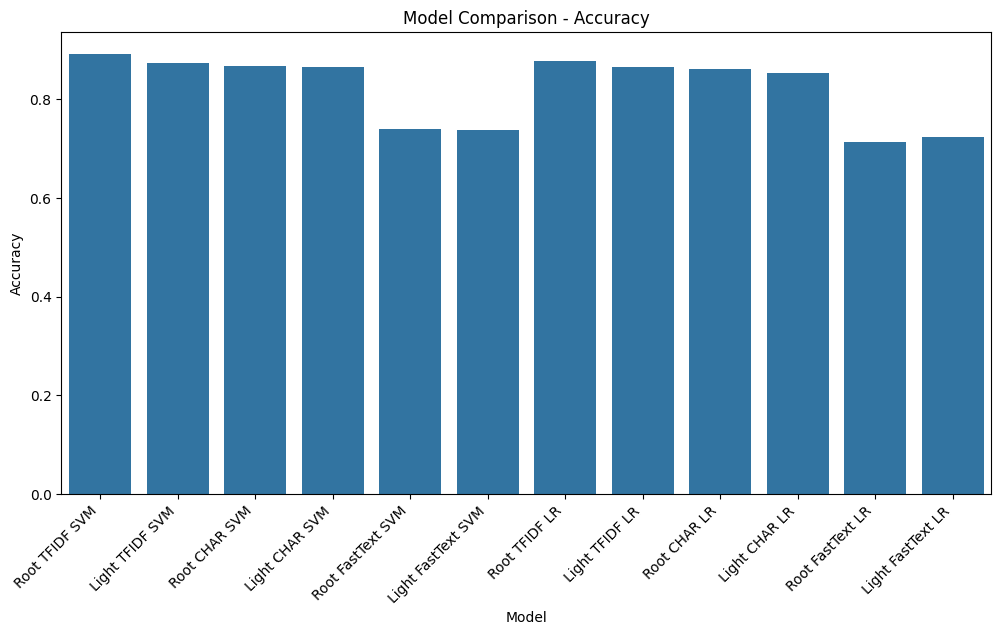

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df_results, x="Model", y="Accuracy")
plt.xticks(rotation=45, ha='right')
plt.title("Model Comparison - Accuracy")
plt.show()

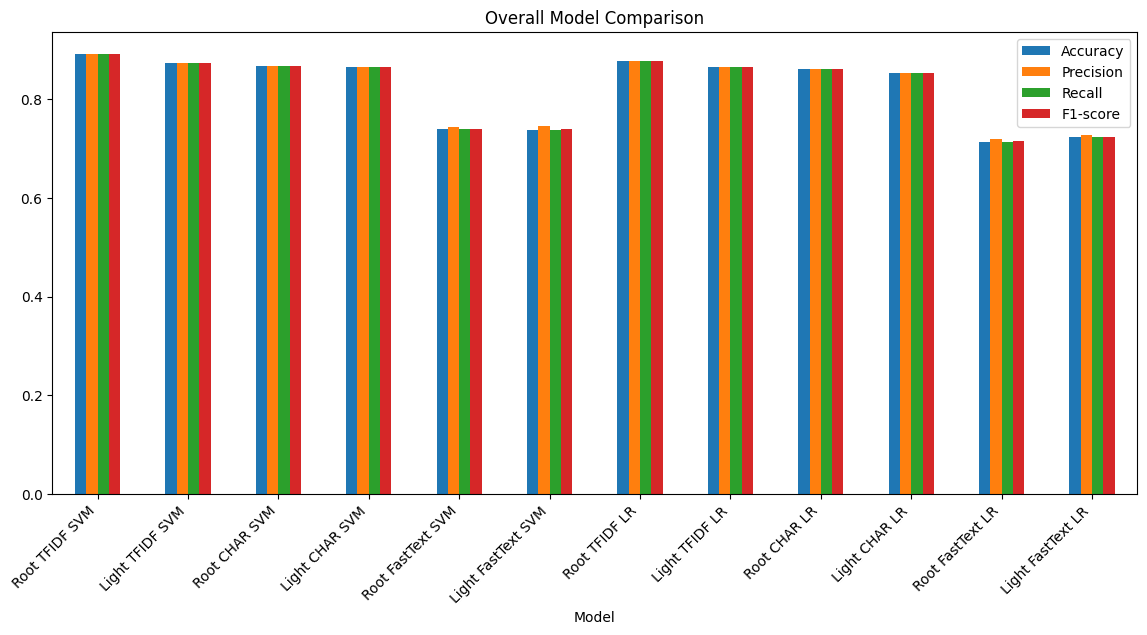

In [ ]:
df_plot = df_results.set_index("Model")

df_plot[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Overall Model Comparison")
plt.xticks(rotation=45, ha='right')
plt.show()

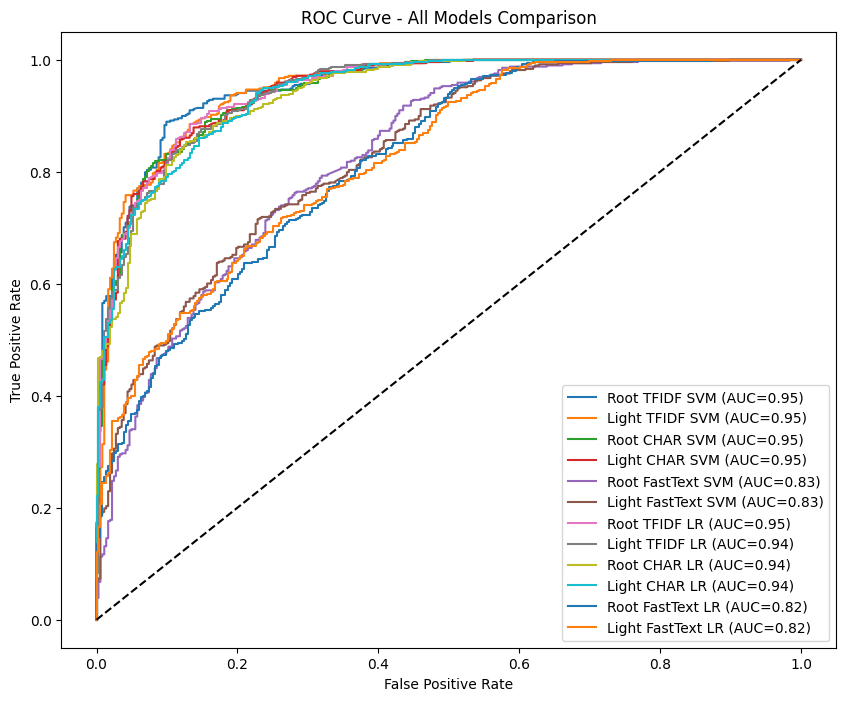

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

def plot_roc(model, X_test, y_test, name):
    y_score = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")


# 🔷 SVM
plot_roc(svm_root_TF, X_test_tfr, y_test_root, "Root TFIDF SVM")
plot_roc(svm_light_TF, X_test_tfl, y_test_light, "Light TFIDF SVM")
plot_roc(svm_root_char, X_test_chr, y_test_root, "Root CHAR SVM")
plot_roc(svm_light_char, X_test_chl, y_test_light, "Light CHAR SVM")
plot_roc(
    svm_root_fasttext,
    X_test_ft_root,
    y_test_root,
    "Root FastText SVM"
)

plot_roc(
    svm_light_fasttext,
    X_test_ft_light,
    y_test_light,
    "Light FastText SVM"
)
# 🟢 LR
plot_roc(lr_root_tfidf, X_test_tfr, y_test_root, "Root TFIDF LR")
plot_roc(lr_light_tfidf, X_test_tfl, y_test_light, "Light TFIDF LR")
plot_roc(lr_root_char, X_test_chr, y_test_root, "Root CHAR LR")
plot_roc(lr_light_char, X_test_chl, y_test_light, "Light CHAR LR")
plot_roc(
    lr_root_fasttext,
    X_test_ft_root,
    y_test_root,
    "Root FastText LR"
)

plot_roc(
    lr_light_fasttext,
    X_test_ft_light,
    y_test_light,
    "Light FastText LR"
)
# خط المنتصف
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models Comparison")
plt.legend()
plt.show()

In [ ]:
results_time = []

def measure_time(model, X_train, y_train, X_test, name):
    import time

    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    start_pred = time.time()
    model.predict(X_test)
    end_pred = time.time()

    results_time.append([
        name,
        end_train - start_train,
        end_pred - start_pred
    ])
#-----------SVM-----------
measure_time(svm_root_TF, X_train_tfr, y_train_root, X_test_tfr, "Root TFIDF SVM")
measure_time(svm_light_TF, X_train_tfl, y_train_light, X_test_tfl, "Light TFIDF SVM")

measure_time(svm_root_char, X_train_chr, y_train_root, X_test_chr, "Root CHAR SVM")
measure_time(svm_light_char, X_train_chl, y_train_light, X_test_chl, "Light CHAR SVM")

measure_time(
    svm_root_fasttext,
    X_train_ft_root,
    y_train_root,
    X_test_ft_root,
    "Root FastText SVM"
)
measure_time(
    svm_light_fasttext,
    X_train_ft_light,
    y_train_light,
    X_test_ft_light,
    "Light FastText SVM"
)


#----------LR--------------
measure_time(lr_root_tfidf, X_train_tfr, y_train_root, X_test_tfr, "Root TFIDF LR")
measure_time(lr_light_tfidf, X_train_tfl, y_train_light, X_test_tfl, "Light TFIDF LR")

measure_time(lr_root_char, X_train_chr, y_train_root, X_test_chr, "Root CHAR LR")
measure_time(lr_light_char, X_train_chl, y_train_light, X_test_chl, "Light CHAR LR")

measure_time(
    lr_root_fasttext,
    X_train_ft_root,
    y_train_root,
    X_test_ft_root,
    "Root FastText LR"
)

measure_time(
    lr_light_fasttext,
    X_train_ft_light,
    y_train_light,
    X_test_ft_light,
    "Light FastText LR"
)
import pandas as pd

df_time = pd.DataFrame(results_time, columns=[
    "Model",
    "Training Time (sec)",
    "Prediction Time (sec)"
])

df_time

,Model,Training Time (sec),Prediction Time (sec)
0,Root TFIDF SVM,7.928252,0.303090
1,Light TFIDF SVM,6.290014,0.262100
2,Root CHAR SVM,30.142626,1.279854
3,Light CHAR SVM,34.517472,1.901988
4,Root FastText SVM,2.586365,0.066037
5,Light FastText SVM,2.386503,0.066397
6,Root TFIDF LR,0.039538,0.000350
7,Light TFIDF LR,0.025795,0.000331
8,Root CHAR LR,0.051131,0.000732
9,Light CHAR LR,0.057076,0.000589


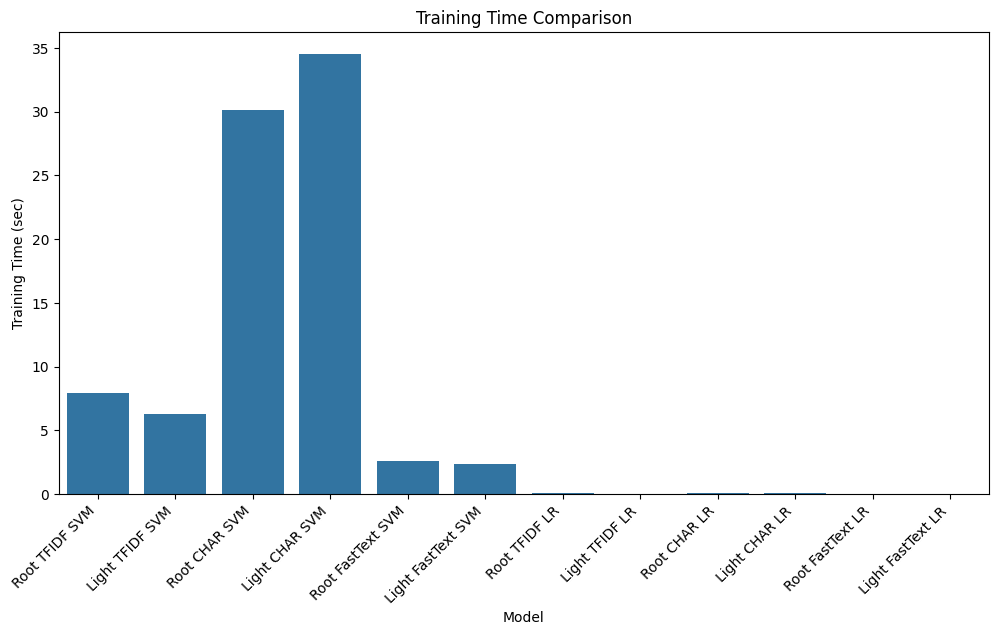

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#Training Time
plt.figure(figsize=(12,6))
sns.barplot(data=df_time, x="Model", y="Training Time (sec)")
plt.xticks(rotation=45, ha='right')
plt.title("Training Time Comparison")
plt.show()

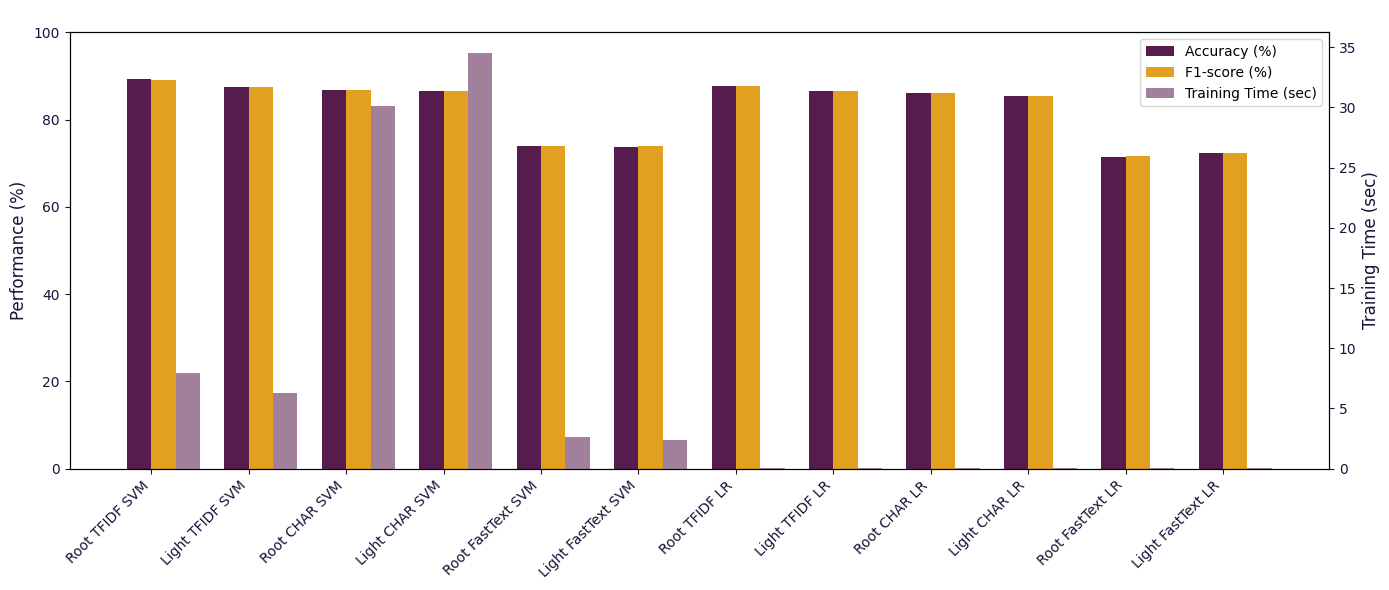

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = df_time["Model"]

accuracy = df_results["Accuracy"] * 100
f1 = df_results["F1-score"] * 100
training_time = df_time["Training Time (sec)"]

x = np.arange(len(models))
width = 0.25

colors = {
    "accuracy": "#551C4D",
    "f1": "#E2A020",
    "time": "#886082"
}

fig, ax1 = plt.subplots(figsize=(14,6))

# Accuracy و F1
ax1.bar(
    x - width/2,
    accuracy,
    width,
    label="Accuracy (%)",
    color=colors["accuracy"]
)

ax1.bar(
    x + width/2,
    f1,
    width,
    label="F1-score (%)",
    color=colors["f1"]
)

ax1.set_ylabel("Performance (%)", fontsize=12)
ax1.set_ylim(0,100)

ax2 = ax1.twinx()

ax2.bar(
    x + width*1.5,
    training_time,
    width,
    label="Training Time (sec)",
    color=colors["time"],
    alpha=0.8
)

ax2.set_ylabel("Training Time (sec)", fontsize=12)



ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha="right")

plt.title(
    "Performance and Training Time Comparison",
    fontsize=16,
    fontweight="bold"
)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines + lines2,
    labels + labels2,
    loc="upper right"
)

fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

ax1.tick_params(colors="white")
ax2.tick_params(colors="white")
ax1.tick_params(colors="#1E1038")
ax2.tick_params(colors="#1E1038")

ax1.yaxis.label.set_color("#1E1038")
ax2.yaxis.label.set_color("#1E1038")

plt.title("Performance and Training Time Comparison", color="white")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

auc_values = []

models = [
    (svm_root_TF, X_test_tfr, y_test_root),
    (svm_light_TF, X_test_tfl, y_test_light),
    (svm_root_char, X_test_chr, y_test_root),
    (svm_light_char, X_test_chl, y_test_light),
    (lr_root_tfidf, X_test_tfr, y_test_root),
    (lr_light_tfidf, X_test_tfl, y_test_light),
    (lr_root_char, X_test_chr, y_test_root),
    (lr_light_char, X_test_chl, y_test_light),
    (svm_root_fasttext, X_test_ft_root, y_test_root),
    (svm_light_fasttext, X_test_ft_light, y_test_light),
    (lr_root_fasttext, X_test_ft_root, y_test_root),
    (lr_light_fasttext, X_test_ft_light, y_test_light),
]

for model, X, y in models:
    auc_values.append(roc_auc_score(y, model.predict_proba(X)[:,1]))

df_results["AUC"] = auc_values
df_all = df_results.copy()
df_all["Training Time"] = df_time["Training Time (sec)"]
df_all["Prediction Time"] = df_time["Prediction Time (sec)"]
df_all

,Model,Accuracy,Precision,Recall,F1-score,AUC,Training Time,Prediction Time
0,Root TFIDF SVM,0.891892,0.891774,0.891892,0.891813,0.953168,7.928252,0.303090
1,Light TFIDF SVM,0.874266,0.874184,0.874266,0.873777,0.950142,6.290014,0.262100
2,Root CHAR SVM,0.868390,0.868150,0.868390,0.868192,0.945502,30.142626,1.279854
3,Light CHAR SVM,0.866040,0.866143,0.866040,0.866086,0.946439,34.517472,1.901988
4,Root FastText SVM,0.739130,0.743740,0.739130,0.740258,0.947833,2.586365,0.066037
5,Light FastText SVM,0.737955,0.746446,0.737955,0.739346,0.944418,2.386503,0.066397
6,Root TFIDF LR,0.877791,0.877571,0.877791,0.877557,0.939112,0.039538,0.000350
7,Light TFIDF LR,0.866040,0.865919,0.866040,0.865487,0.942589,0.025795,0.000331
8,Root CHAR LR,0.861340,0.861176,0.861340,0.861238,0.828013,0.051131,0.000732
9,Light CHAR LR,0.853114,0.853064,0.853114,0.853088,0.831264,0.057076,0.000589


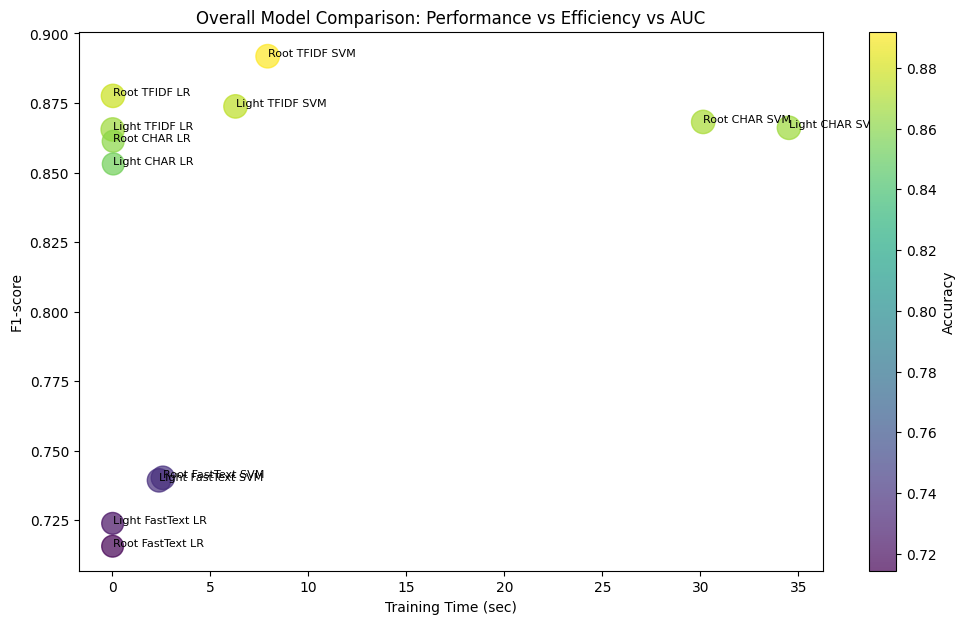

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

scatter = plt.scatter(
    df_all["Training Time"],
    df_all["F1-score"],
    s=df_all["AUC"] * 300,
    c=df_all["Accuracy"],
    cmap="viridis",
    alpha=0.7
)

# models name
for i in range(len(df_all)):
    plt.text(
        df_all["Training Time"][i],
        df_all["F1-score"][i],
        df_all["Model"][i],
        fontsize=8
    )

plt.colorbar(scatter, label="Accuracy")

plt.xlabel("Training Time (sec)")
plt.ylabel("F1-score")
plt.title("Overall Model Comparison: Performance vs Efficiency vs AUC")

plt.show()

# Error Analysis

In [ ]:

# Select Best Model

models_dict = {
    "Root TFIDF SVM": (svm_root_TF, X_test_tfr, X_test_root, y_test_root),
    "Light TFIDF SVM": (svm_light_TF, X_test_tfl, X_test_light, y_test_light),
    "Root CHAR SVM": (svm_root_char, X_test_chr, X_test_root, y_test_root),
    "Light CHAR SVM": (svm_light_char, X_test_chl, X_test_light, y_test_light),
    "Root FastText SVM": (svm_root_fasttext, X_test_ft_root, X_test_root, y_test_root),
    "Light FastText SVM": (svm_light_fasttext, X_test_ft_light, X_test_light, y_test_light),

    "Root TFIDF LR": (lr_root_tfidf, X_test_tfr, X_test_root, y_test_root),
    "Light TFIDF LR": (lr_light_tfidf, X_test_tfl, X_test_light, y_test_light),
    "Root CHAR LR": (lr_root_char, X_test_chr, X_test_root, y_test_root),
    "Light CHAR LR": (lr_light_char, X_test_chl, X_test_light, y_test_light),
    "Root FastText LR": (lr_root_fasttext, X_test_ft_root, X_test_root, y_test_root),
    "Light FastText LR": (lr_light_fasttext, X_test_ft_light, X_test_light, y_test_light)
}


# Get best model based on F1-score or Accuracy
best_name = df_results.loc[
    df_results["F1-score"].idxmax(),
    "Model"
]

print("Best Model:", best_name)


best_model, X_best_test, X_best_text, y_best_test = models_dict[best_name]


# Error Analysis

y_pred = best_model.predict(X_best_test)


errors = pd.DataFrame({
    "Text": X_best_text.values,
    "True_Label": y_best_test.values,
    "Predicted_Label": y_pred
})


errors = errors[
    errors["True_Label"] != errors["Predicted_Label"]
]


print("Number of Errors:", len(errors))

errors.head(20)

Best Model: Root TFIDF SVM
Number of Errors: 92


,Text,True_Label,Predicted_Label
9,فهم حين ليش عود ضد سقط ولي قيد راه وتم راه وكل...,1,0
35,سعد رفض سقط ولي لن سقط ولي معو صيح,0,1
46,بنت سقط ولي يقص الل يخذ وحد ورا ثني قول امن,0,1
59,وقع زوج جند ربط و الي علي لحد كيف صرف جيب وفق ...,1,0
84,عكس ، غلب نسء الل هلي رفض وظف خلط او نقل مدن ك...,1,0
102,ولل لقد مر بي كثر من تزج رافضو عدد زوج وهم غرق...,1,0
103,هذا قطع قدم قبل قيد مراه،، وفه بنت حتج نهم يسق...,1,0
116,سعد طلب سقط ولايه717 بعد طلب سقط ولي طلب يا سق...,0,1
124,عدد زوج ليت بكف ولل كان زوج شبب ثنت ثلث ربع كل...,1,0
129,ولد تزج 5 رات وتح الن ثلث زوج و رزق الل نهن 21...,1,0


In [ ]:

# McNemar Test


from statsmodels.stats.contingency_tables import mcnemar


pred_svm = svm_root_TF.predict(X_test_tfr)

pred_lr = lr_root_tfidf.predict(X_test_tfr)


table = [[0,0],
         [0,0]]


for svm_pred, lr_pred, true in zip(
    pred_svm,
    pred_lr,
    y_test_root
):

    svm_correct = svm_pred == true
    lr_correct = lr_pred == true


    if svm_correct and lr_correct:
        table[0][0] += 1

    elif svm_correct and not lr_correct:
        table[0][1] += 1

    elif not svm_correct and lr_correct:
        table[1][0] += 1

    else:
        table[1][1] += 1


print("Contingency Table:")
print(table)


result = mcnemar(
    table,
    exact=False,
    correction=True
)


print("McNemar statistic:", result.statistic)
print("p-value:", result.pvalue)

Contingency Table:
[[738, 21], [9, 83]]
McNemar statistic: 4.033333333333333
p-value: 0.04460971802493953


In [ ]:
# Wilcoxon Signed-Rank Test


from scipy.stats import wilcoxon


# SVM Root TFIDF
svm_scores = cross_val_score(
    svm.SVC(
        C=1.0,
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfr,
    y_train_root,
    cv=cv,
    scoring="f1_weighted"
)


# LR Root TFIDF
lr_scores = cross_val_score(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    X_train_tfr,
    y_train_root,
    cv=cv,
    scoring="f1_weighted"
)


stat, p_value = wilcoxon(
    svm_scores,
    lr_scores
)


print("SVM scores:", svm_scores)
print("LR scores:", lr_scores)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

SVM scores: [0.88899362 0.88501391 0.88524235 0.87564821 0.89131179 0.87386407
 0.87347233 0.86770435 0.90805168 0.86746785]
LR scores: [0.88585055 0.89980831 0.90023226 0.88501391 0.88254369 0.88566567
 0.85869348 0.87965066 0.88448108 0.86129195]
Wilcoxon statistic: 23.0
p-value: 0.6953125
